In [10]:
from labdata.schema import (
    Subject,
    SpikeSorting,
    Dataset,
    Session,
    UnitMetrics,
    EphysRecording,
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from matplotlib.axes import Axes
import textwrap
from diptest import diptest
import ipywidgets as widgets
from IPython.display import display

%matplotlib widget

In [11]:
subject_name = "GRB058"

# None = auto-fetch all sessions with spike sorting for this subject
session_names = None  # GRB058 - ["20260224_152424"]

unit_criteria = {
    "isi_contamination": "< 0.1",
    "amplitude_cutoff": "< 0.1",
    "spike_duration": "> 0.1",
    "spike_amplitude": "> 50",
    "presence_ratio": "> 0.6",
    "firing_rate": "> 1",
}

depth_drift_threshold = 6
amp_drift_threshold = 0.10
dip_p_threshold = 0.6

n_chunks = 5
n_bins = 50

In [12]:
def analyze_unit(
    arr, i, n_chunks=5, bins=50, print_fig=False, print_stats=False, unit_id=None
):
    arr = np.asarray(arr)

    if len(arr) < n_chunks:
        print(f"Unit {i} too short")
        return None

    chunks = np.array_split(arr, n_chunks)

    if print_fig:
        plt.figure()
        for j, chunk in enumerate(chunks):
            plt.hist(
                chunk, bins=bins, histtype="step", alpha=0.8, label=f"Chunk {j + 1}"
            )
        plt.title(f"Unit {unit_id}")
        plt.xlabel("Spike amplitude")
        plt.ylabel("Count")
        plt.legend()

    means = np.array([np.mean(chunk) for chunk in chunks])
    drift = (means.max() - means.min()) / means.mean()

    dip_stats = []
    dip_pvals = []
    for chunk in chunks:
        dip, p = diptest(chunk)  # type: ignore
        dip_stats.append(dip)
        dip_pvals.append(p)

    mean_dip = np.mean(dip_stats)
    mean_dip_p = np.mean(dip_pvals)

    if print_stats:
        print(f"unit id = {unit_id}")
        print(f"Drift = {drift:.3f}")
        print(f"Mean Dip = {mean_dip:.4f}")
        print(f"Mean Dip p = {mean_dip_p:.4g}")

    return {
        "drift": drift,
        "mean_dip": mean_dip,
        "mean_dip_p": mean_dip_p,
        "chunks": chunks,
    }

In [13]:
def analyze_probe_stability(
    all_units_df,
    single_units_df,
    single_units_before_drift_df,
    n_chunks=5,
    n_bins=50,
    amp_drift_threshold=0.10,
    dip_p_threshold=0.6,
    verbose=False,
):
    """Analyze spike amplitude stability for all single units on one probe.

    Returns (analysis_df, change_in_unit_count, single_unit_spiking_info).
    """
    matching_indices = np.where(np.isin(all_units_df.unit_id, single_units_df.unit_id))[
        0
    ]
    single_unit_spiking_info = all_units_df.iloc[matching_indices]

    all_cell_analysis = []
    for unit_idx in range(len(single_unit_spiking_info)):
        y = single_unit_spiking_info.spike_amplitudes.iloc[unit_idx]
        unit_id = single_unit_spiking_info.unit_id.values[unit_idx]
        cell_analysis = analyze_unit(
            y,
            unit_idx,
            n_chunks=n_chunks,
            bins=n_bins,
            print_fig=verbose,
            print_stats=verbose,
            unit_id=unit_id,
        )
        all_cell_analysis.append(cell_analysis)

    analysis_df = pd.DataFrame(all_cell_analysis)

    high_amp_drift = analysis_df.index[
        analysis_df["drift"] > amp_drift_threshold
    ].tolist()
    high_bimodal = analysis_df.index[
        analysis_df["mean_dip_p"] < dip_p_threshold
    ].tolist()

    n_after_unimodal = len(single_units_df) - len(high_bimodal)
    high_amp_not_bimodal = list(set(high_amp_drift) - set(high_bimodal))
    n_after_amp_drift = n_after_unimodal - len(high_amp_not_bimodal)

    change_in_unit_count = [
        len(single_units_before_drift_df),  # KS4.0
        len(single_units_df),  # + electrode drift
        n_after_unimodal,  # + unimodal
        n_after_amp_drift,  # + amplitude drift
    ]

    return analysis_df, change_in_unit_count, single_unit_spiking_info

In [14]:
if session_names is None:
    session_names = list(
        (
            (Subject() & f'subject_name = "{subject_name}"').proj() * SpikeSorting()
        ).fetch("session_name")
    )
    print(f"Auto-fetched {len(session_names)} sessions for {subject_name}")
else:
    print(f"Using {len(session_names)} specified sessions for {subject_name}")

sua_restrictions = [f"{col} {op}" for col, op in unit_criteria.items()]

print(f"Sessions: {session_names}")  # type: ignore
print(f"SUA criteria: {sua_restrictions}")

Auto-fetched 1 sessions for GRB058
Sessions: ['20260224_152424']
SUA criteria: ['isi_contamination < 0.1', 'amplitude_cutoff < 0.1', 'spike_duration > 0.1', 'spike_amplitude > 50', 'presence_ratio > 0.6', 'firing_rate > 1']


In [15]:
change_in_unit_counts = {}
probe_widget_data = {}

for this_session in session_names:
    session_restr = f'session_name = "{this_session}"'
    subject_restr = f'subject_name = "{subject_name}"'

    animal_session = (SpikeSorting & subject_restr) & session_restr
    spikesortingprobes = animal_session.proj().fetch(as_dict=True)

    all_sessions = Session & (SpikeSorting() & dict(subject_name=subject_name))
    ephys_dataset = (
        (Dataset & all_sessions & session_restr & 'dataset_name LIKE "ephys%"')
        .proj()
        .fetch(as_dict=True)
    )
    selected_session = (Session & ephys_dataset[0]).fetch1()

    probe_nums = (EphysRecording.ProbeSetting() & selected_session).fetch("probe_num")
    print(f"Session {this_session}: found probes {list(probe_nums)}")

    sua = UnitMetrics() & session_restr
    for restr in sua_restrictions:
        sua = sua & restr
    sua_depth_stability = sua & f"depth_drift_start_to_end < {depth_drift_threshold}"

    for probe_num in probe_nums:
        probe_restr = f"probe_num = {probe_num}"
        probe_key = [k for k in spikesortingprobes if k["probe_num"] == probe_num]

        all_units_df = pd.DataFrame(
            (SpikeSorting.Unit * UnitMetrics & probe_key).fetch()
        )
        single_units_df = pd.DataFrame(sua_depth_stability & probe_restr)
        single_units_before_drift_df = pd.DataFrame(sua & probe_restr)

        analysis_df, unit_count, spiking_info = analyze_probe_stability(
            all_units_df,
            single_units_df,
            single_units_before_drift_df,
            n_chunks=n_chunks,
            n_bins=n_bins,
            amp_drift_threshold=amp_drift_threshold,
            dip_p_threshold=dip_p_threshold,
            verbose=False,
        )

        change_in_unit_counts.setdefault(probe_num, []).append(unit_count)

        unit_ids = list(spiking_info.unit_id.values)
        spike_amps = [
            spiking_info.spike_amplitudes.iloc[i] for i in range(len(spiking_info))
        ]
        probe_widget_data[(this_session, probe_num)] = {
            "analysis_df": analysis_df,
            "unit_ids": unit_ids,
            "spike_amplitudes": spike_amps,
        }

print(f"\nProbes analyzed: {list(change_in_unit_counts.keys())}")
for pn, counts in change_in_unit_counts.items():
    print(f"  imec{pn}: {len(counts)} session(s)")

Session 20260224_152424: found probes [np.int64(0)]

Probes analyzed: [np.int64(0)]
  imec0: 1 session(s)


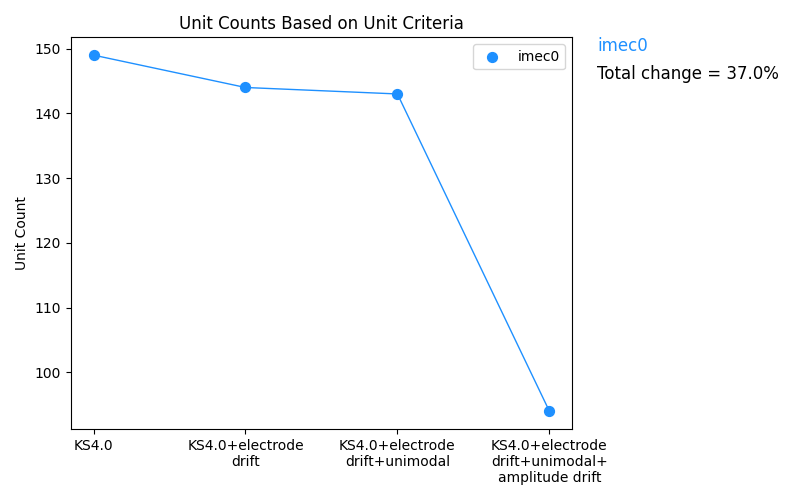

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

for idx, (probe_num, counts_list) in enumerate(sorted(change_in_unit_counts.items())):
    for counts in counts_list:
        ax.plot(counts, color="dodgerblue", linewidth=1)
    ax.scatter(
        [0, 1, 2, 3],
        np.mean(counts_list, axis=0),
        s=50,
        color="dodgerblue",
        label=f"imec{probe_num}",
    )
    first = counts_list[0]
    if first[0] > 0:
        pct_change = round((first[0] - first[-1]) / first[0], 2) * 100
    else:
        pct_change = 0
    y_pos = 1.0 - idx * 0.14
    ax.text(
        1.05,
        y_pos,
        f"imec{probe_num}",
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment="top",
        color="dodgerblue",
    )
    ax.text(
        1.05,
        y_pos - 0.07,
        f"Total change = {pct_change}%",
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment="top",
    )

ax.set_title("Unit Counts Based on Unit Criteria")
ax.set_ylabel("Unit Count")
tick_positions = [0, 1, 2, 3]
long_labels = [
    "KS4.0",
    "KS4.0+electrode drift",
    "KS4.0+electrode drift+unimodal",
    "KS4.0+electrode drift+unimodal+amplitude drift",
]
wrapped_labels = [textwrap.fill(label, 15) for label in long_labels]
ax.set_xticks(tick_positions, wrapped_labels)
ax.legend()
fig.tight_layout()

In [17]:
class StabilityBrowser:
    """Interactive widget for browsing per-unit amplitude stability analysis."""

    FILTER_OPTIONS = [
        "All",
        "Flagged: high drift",
        "Flagged: bimodal",
        "Flagged: fail both",
        "Stable only",
    ]

    def __init__(
        self,
        probe_widget_data,
        n_chunks=5,
        n_bins=50,
        amp_drift_threshold=0.10,
        dip_p_threshold=0.6,
    ):
        self.data = probe_widget_data
        self.n_chunks = n_chunks
        self.n_bins = n_bins
        self.amp_drift_threshold = amp_drift_threshold
        self.dip_p_threshold = dip_p_threshold

        self._fig: Figure | None = None
        self._ax: Axes | None = None
        self._updating = False

        self._sessions = sorted({k[0] for k in self.data.keys()})
        self._all_probes = sorted({k[1] for k in self.data.keys()})

        self.session_dropdown = widgets.Dropdown(
            options=self._sessions,
            value=self._sessions[0],
            description="Session:",
        )
        initial_probes = self._available_probes()
        self.probe_dropdown = widgets.Dropdown(
            options=[f"imec{p}" for p in initial_probes],
            value=f"imec{initial_probes[0]}",
            description="Probe:",
        )
        self.filter_radio = widgets.RadioButtons(
            options=self.FILTER_OPTIONS,
            value="All",
            description="Filter:",
        )
        self.unit_slider = widgets.SelectionSlider(
            options=["—"],
            description="Unit:",
            continuous_update=False,
            style={"description_width": "initial"},
            layout=widgets.Layout(width="400px"),
        )
        self.count_label = widgets.HTML(value="")
        self._stats_html = widgets.HTML(value="")

        # wire callbacks
        self.session_dropdown.observe(self._on_session_change, names="value")
        self.probe_dropdown.observe(self._on_probe_or_filter_change, names="value")
        self.filter_radio.observe(self._on_probe_or_filter_change, names="value")
        self.unit_slider.observe(self._on_unit_change, names="value")

    def _available_probes(self):
        """Return sorted list of probe numbers available for the current session."""
        sess = self.session_dropdown.value
        return sorted(k[1] for k in self.data.keys() if k[0] == sess)

    def _current_key(self):
        """Return the (session, probe_num) key for current selections."""
        sess = self.session_dropdown.value
        pn = int(self.probe_dropdown.value.replace("imec", ""))
        return (sess, pn)

    def _filtered_indices(self):
        """Return list of indices into unit_ids/spike_amplitudes/analysis_df for the active filter."""
        df = self.data[self._current_key()]["analysis_df"]
        filt = self.filter_radio.value

        if filt == "All":
            return list(range(len(df)))
        if filt == "Flagged: high drift":
            return df.index[df["drift"] > self.amp_drift_threshold].tolist()
        if filt == "Flagged: bimodal":
            return df.index[df["mean_dip_p"] < self.dip_p_threshold].tolist()
        if filt == "Flagged: fail both":
            return df.index[
                (df["drift"] > self.amp_drift_threshold)
                & (df["mean_dip_p"] < self.dip_p_threshold)
            ].tolist()

        return df.index[
            (df["drift"] <= self.amp_drift_threshold)
            & (df["mean_dip_p"] >= self.dip_p_threshold)
        ].tolist()

    def _on_session_change(self, _change):  # noqa: ARG002
        """Update probe dropdown when session changes, then cascade."""
        self._updating = True
        probes = self._available_probes()
        self.probe_dropdown.options = [f"imec{p}" for p in probes]
        self.probe_dropdown.value = f"imec{probes[0]}"
        self._updating = False
        self._on_probe_or_filter_change(None)

    def _on_probe_or_filter_change(self, _change):  # noqa: ARG002
        if self._updating:
            return
        self._updating = True
        key = self._current_key()
        indices = self._filtered_indices()
        unit_ids = self.data[key]["unit_ids"]

        if indices:
            options = [unit_ids[i] for i in indices]
            self.unit_slider.options = options
            self.unit_slider.value = options[0]
        else:
            self.unit_slider.options = ["—"]
            self.unit_slider.value = "—"

        total = len(unit_ids)
        self.count_label.value = f"<b>{len(indices)}</b> / {total} units"
        self._updating = False
        self._update_display()

    def _on_unit_change(self, _change):  # noqa: ARG002
        if not self._updating:
            self._update_display()

    def _update_display(self):
        assert self._fig is not None and self._ax is not None

        key = self._current_key()
        unit_id = self.unit_slider.value
        if unit_id == "—":
            self._ax.clear()
            self._ax.set_visible(False)
            self._fig.canvas.draw_idle()
            self._stats_html.value = "<i>No units match this filter.</i>"
            return

        unit_ids = self.data[key]["unit_ids"]
        idx = unit_ids.index(unit_id)
        row = self.data[key]["analysis_df"].iloc[idx]
        amps = self.data[key]["spike_amplitudes"][idx]

        drift_ok = row["drift"] <= self.amp_drift_threshold
        dip_ok = row["mean_dip_p"] >= self.dip_p_threshold

        def badge(ok):
            color = "green" if ok else "red"
            text = "PASS" if ok else "FAIL"
            return f'<span style="color:{color};font-weight:bold">{text}</span>'

        self._stats_html.value = f"""
        <div style="font-family:monospace; font-size:13px; line-height:1.8">
        <b>Unit {unit_id}</b><br>
        Amp drift: {row["drift"]:.3f}
            (threshold {self.amp_drift_threshold}) {badge(drift_ok)}<br>
        Mean dip stat: {row["mean_dip"]:.4f}<br>
        Mean dip p-value: {row["mean_dip_p"]:.4g}
            (threshold {self.dip_p_threshold}) {badge(dip_ok)}<br>
        </div>
        """

        ax = self._ax
        ax.clear()
        ax.set_visible(True)

        arr = np.asarray(amps)
        chunks = np.array_split(arr, self.n_chunks)
        for j, chunk in enumerate(chunks):
            ax.hist(
                chunk,
                bins=self.n_bins,
                histtype="step",
                alpha=0.8,
                label=f"Chunk {j + 1}",
            )
        ax.set_title(f"Unit {unit_id}")
        ax.set_xlabel("Spike amplitude")
        ax.set_ylabel("Count")
        ax.legend(fontsize=8)
        self._fig.tight_layout()
        self._fig.canvas.draw_idle()

    def show(self):
        with plt.ioff():
            self._fig, self._ax = plt.subplots(figsize=(5, 3.5))

        selectors = widgets.VBox([self.session_dropdown, self.probe_dropdown])
        controls = widgets.HBox([selectors, self.filter_radio])
        left_panel = widgets.VBox(
            [controls, self._fig.canvas],
            layout=widgets.Layout(align_items="flex-start"),
        )
        right_panel = widgets.VBox(
            [self.unit_slider, self.count_label, self._stats_html],
            layout=widgets.Layout(
                align_items="flex-start",
                justify_content="flex-start",
                margin="0 0 0 20px",
            ),
        )
        body = widgets.HBox(
            [left_panel, right_panel],
            layout=widgets.Layout(align_items="flex-start"),
        )
        display(body)
        self._on_probe_or_filter_change(None)

In [18]:
browser = StabilityBrowser(
    probe_widget_data,
    n_chunks=n_chunks,
    n_bins=n_bins,
    amp_drift_threshold=amp_drift_threshold,
    dip_p_threshold=dip_p_threshold,
)
browser.show()